In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('../mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np

      TZ GeSlab  Code
0   T1Z2    G11   402
1   T1Z5    G09   405
2   T2Z3    G13   413
3   T2Z5    G31   415
4   T3Z2    G25   422
5   T3Z4    G33   424
6   T3Z5    G32   425
7   T3Z6    G29   426
8   T4Z2    G37   432
9   T4Z4    G35   434
10  T4Z5    G34   435
11  T4Z6    G38   436
12  T5Z4    G26   444
13  T5Z5    G39   445
[402 405 413 415 422 424 425 426 432 434 435 436 444 445]
T5Z5_G39_File_445


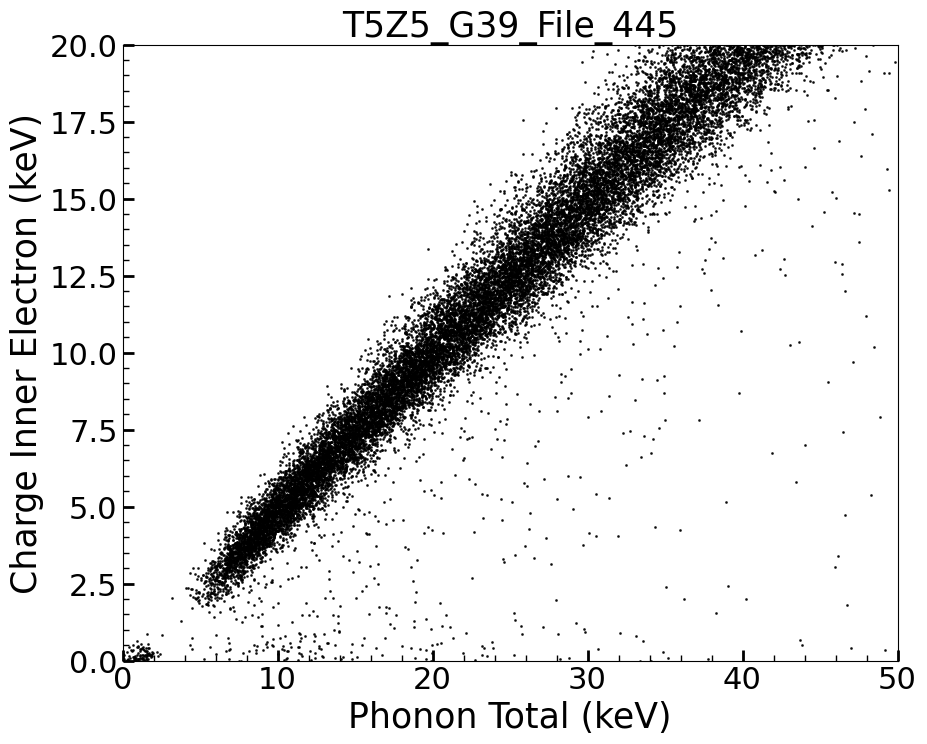

T5Z4_G26_File_444


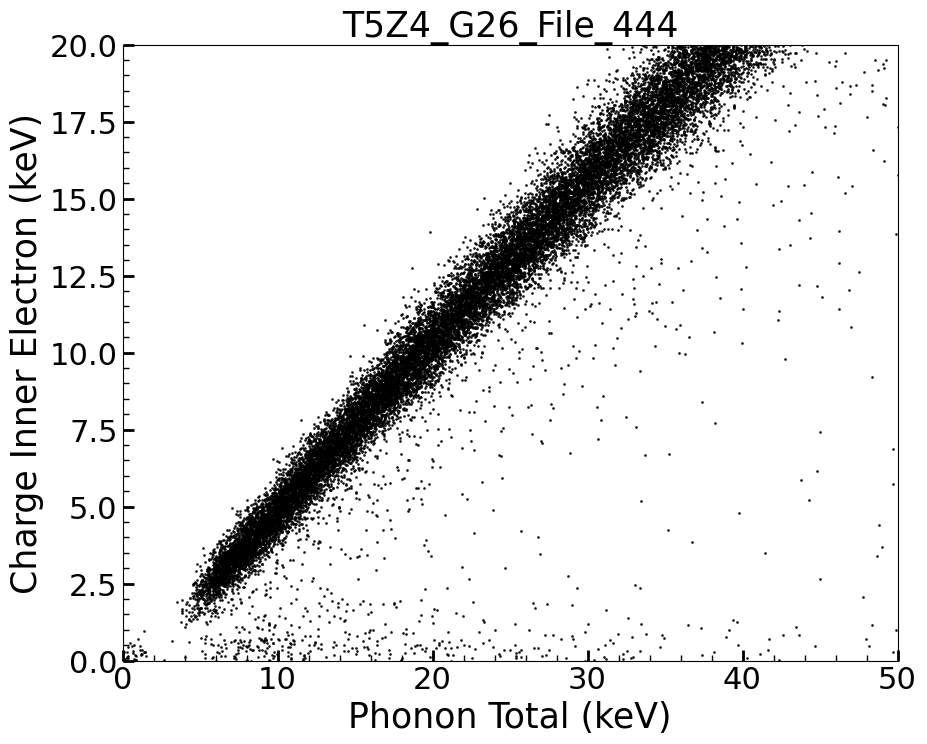

T3Z2_G25_File_422


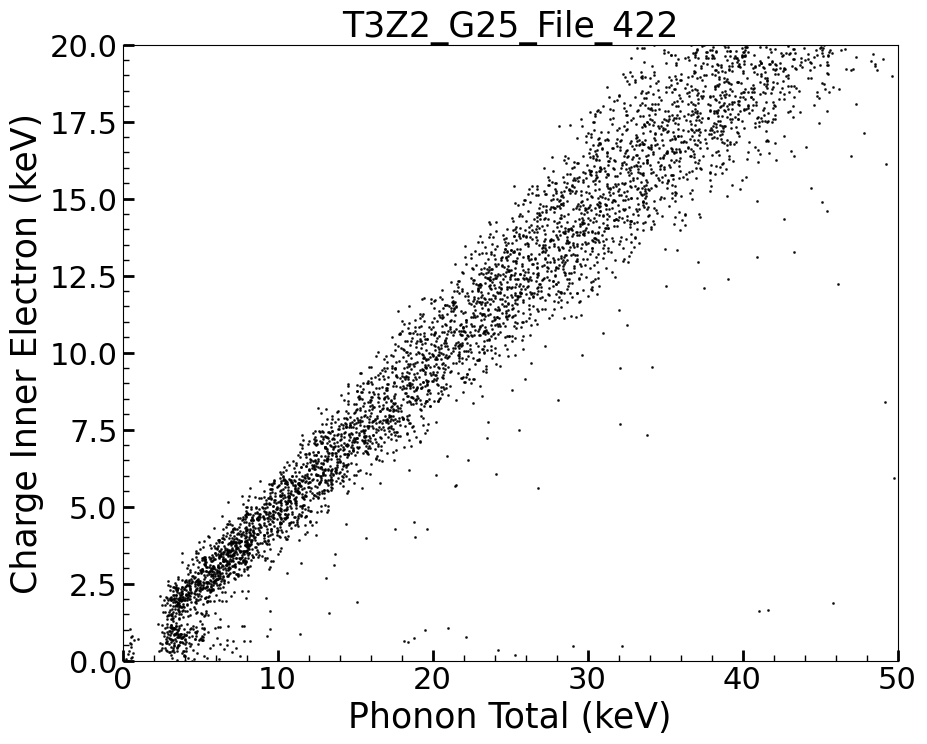

T4Z6_G38_File_436


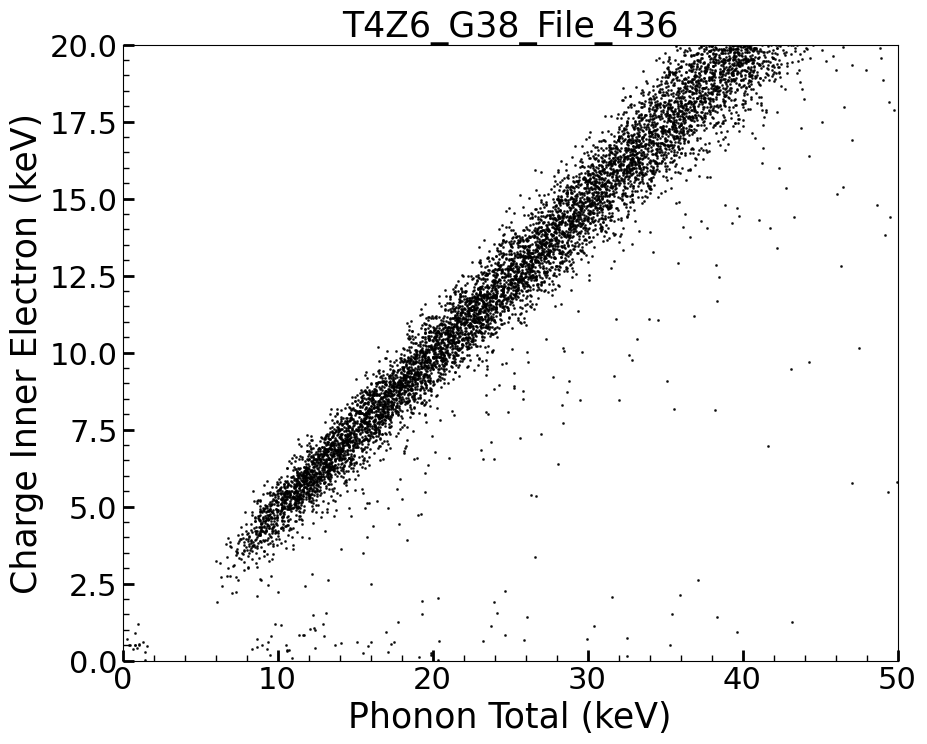

T4Z4_G35_File_434


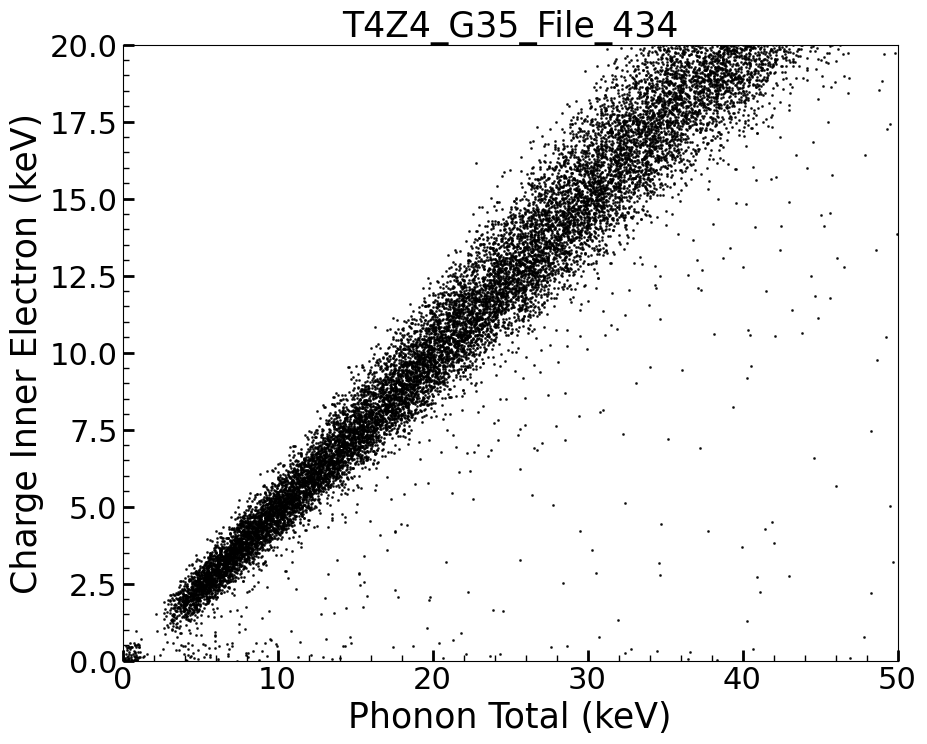

T4Z5_G34_File_435


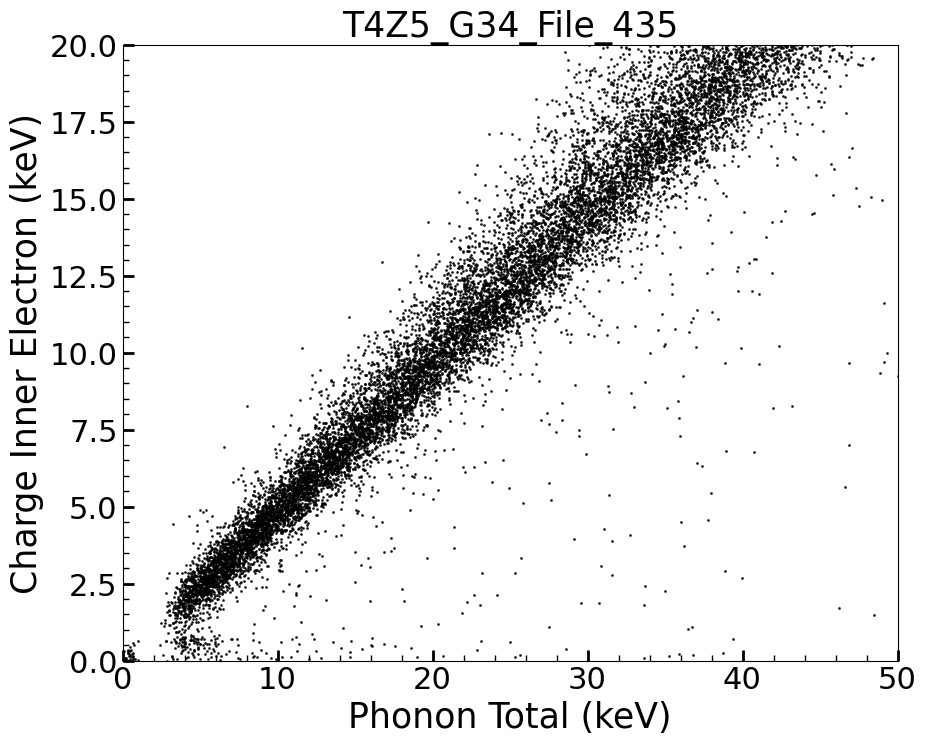

T3Z5_G32_File_425


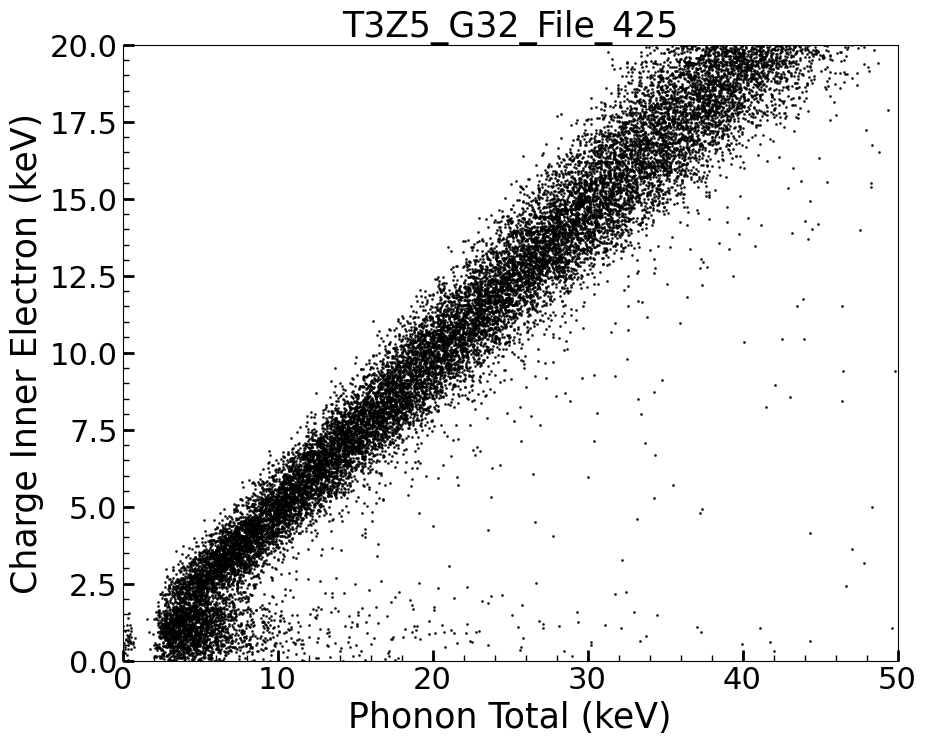

T3Z4_G33_File_424


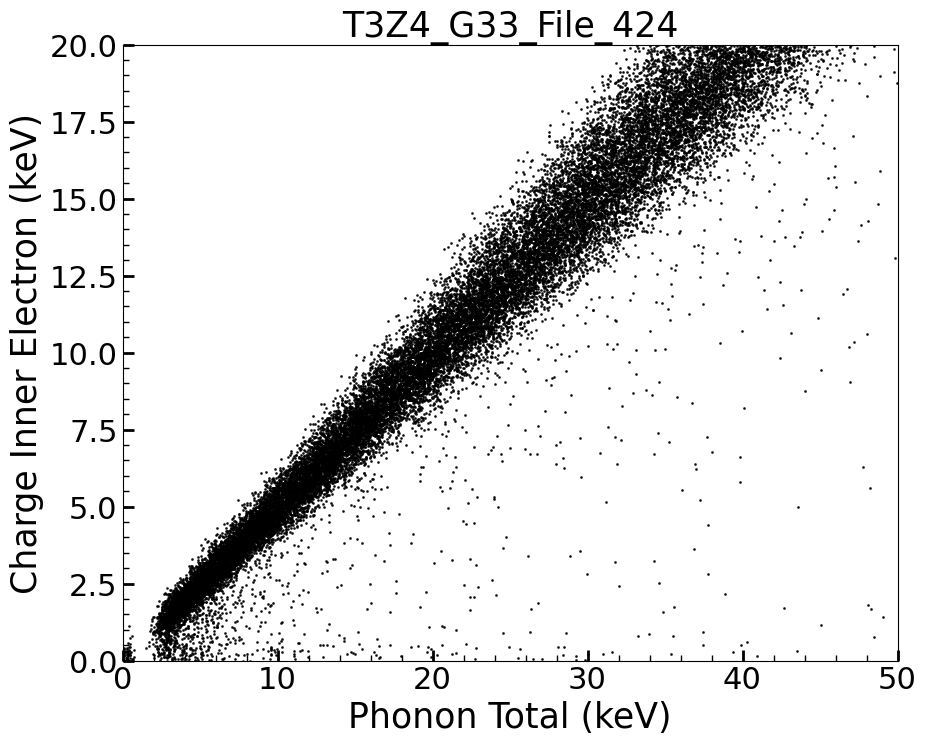

T4Z2_G37_File_432


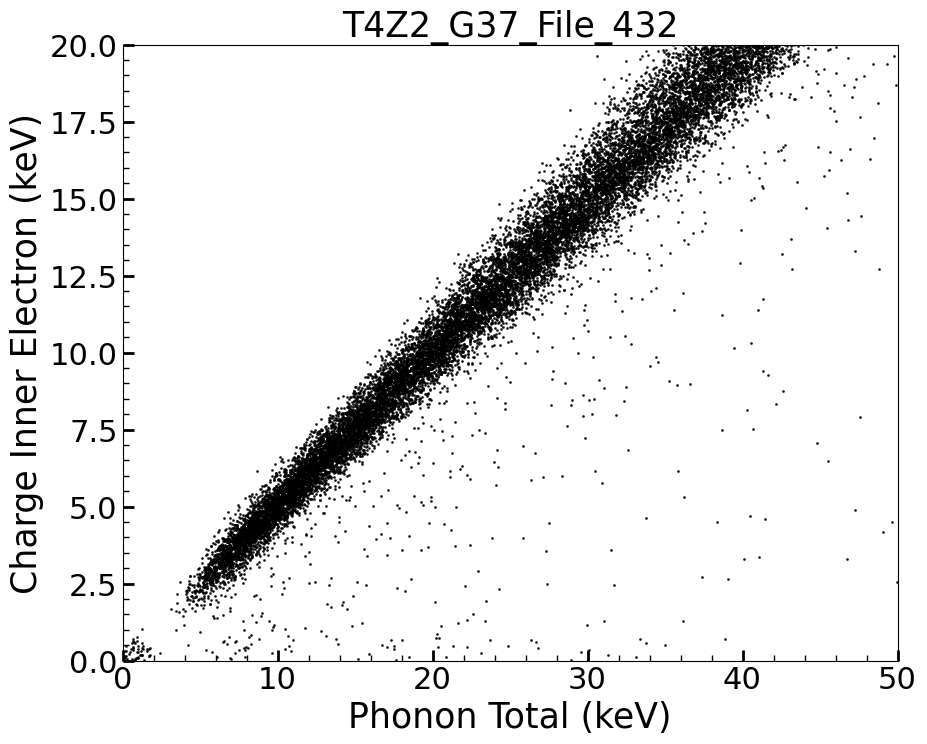

T3Z6_G29_File_426


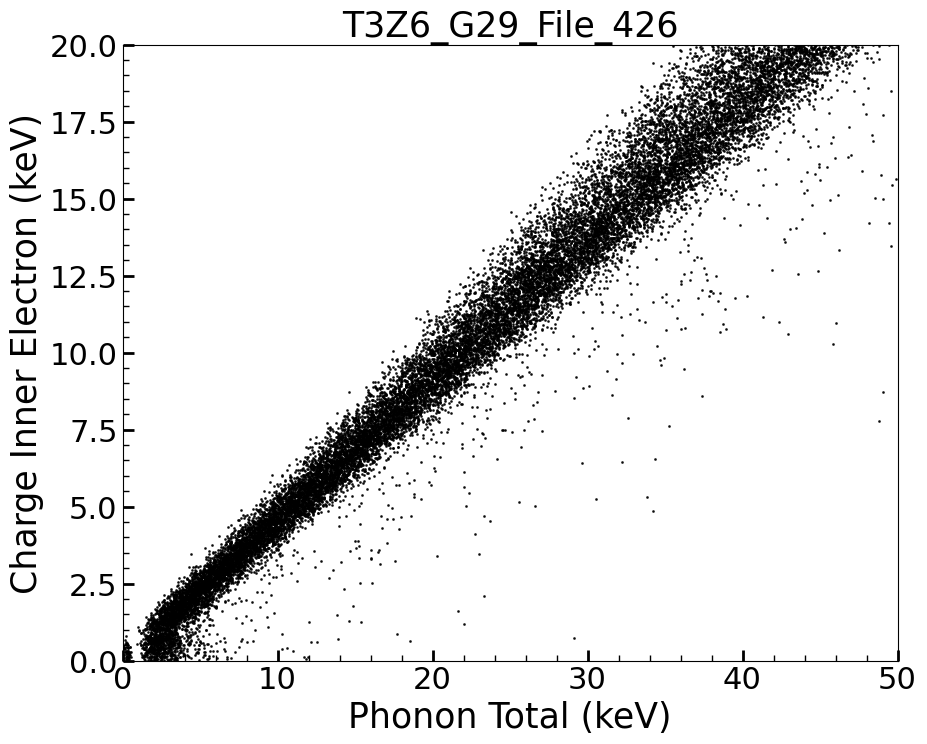

T1Z2_G11_File_402


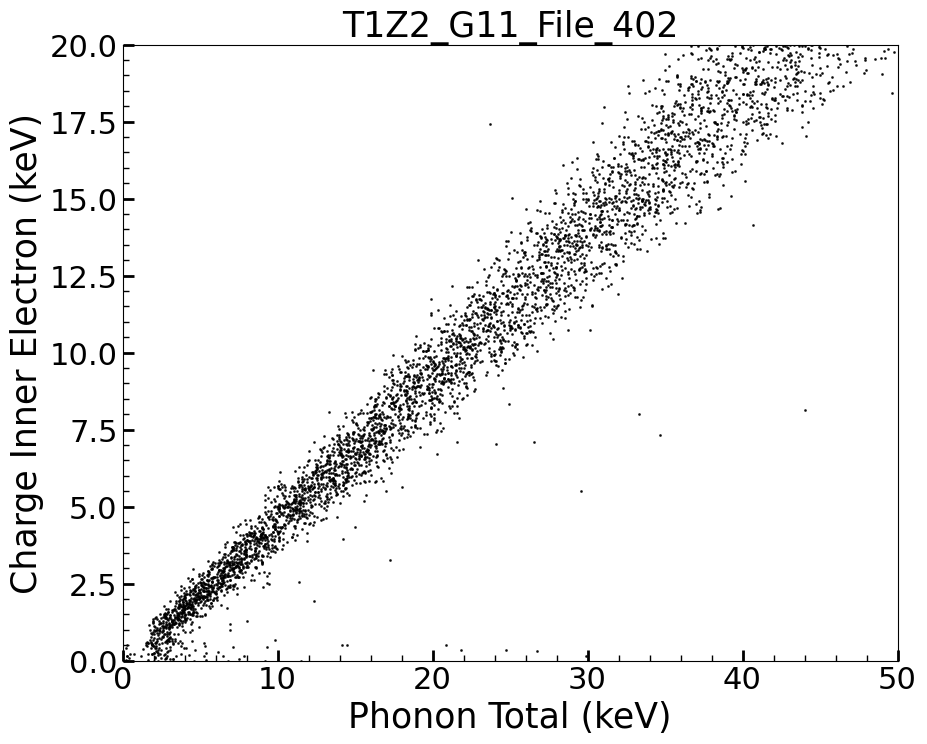

T2Z5_G31_File_415


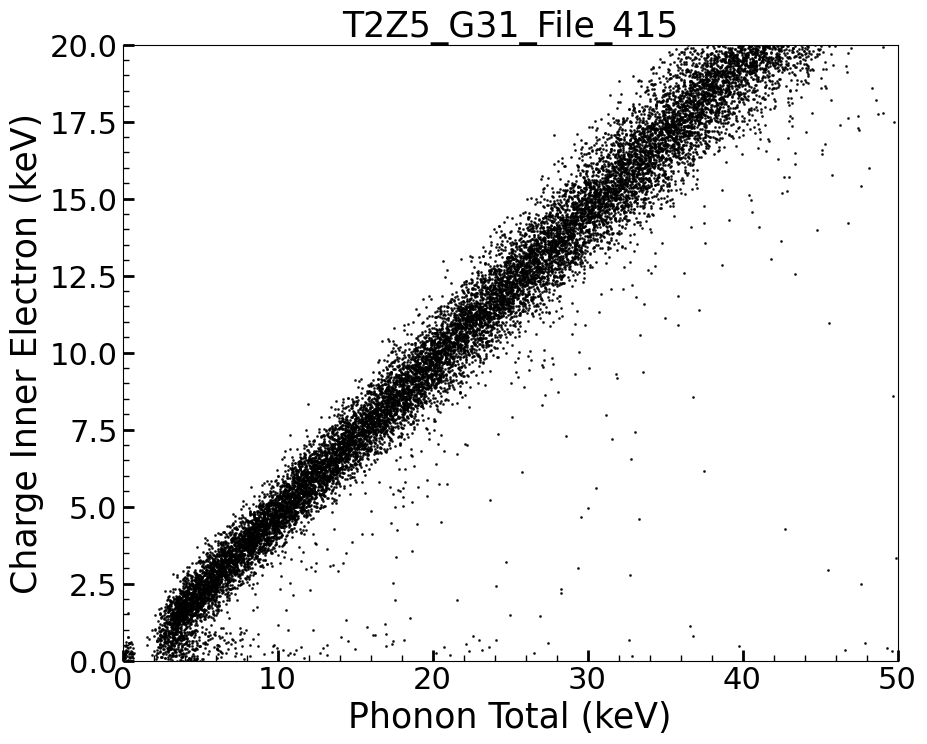

T1Z5_G09_File_405


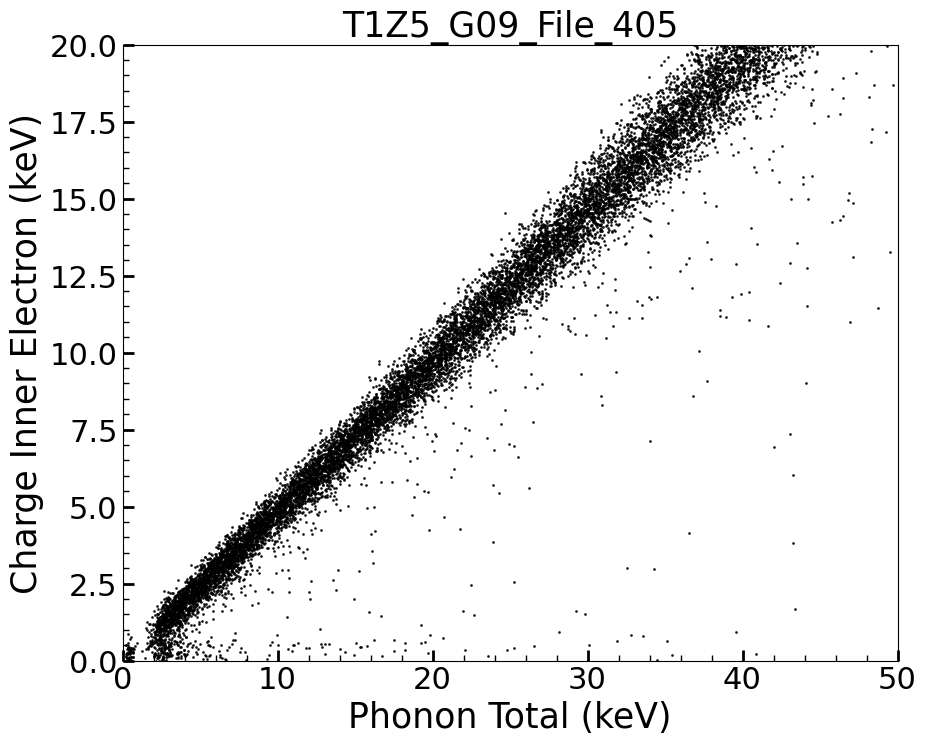

T2Z3_G13_File_413


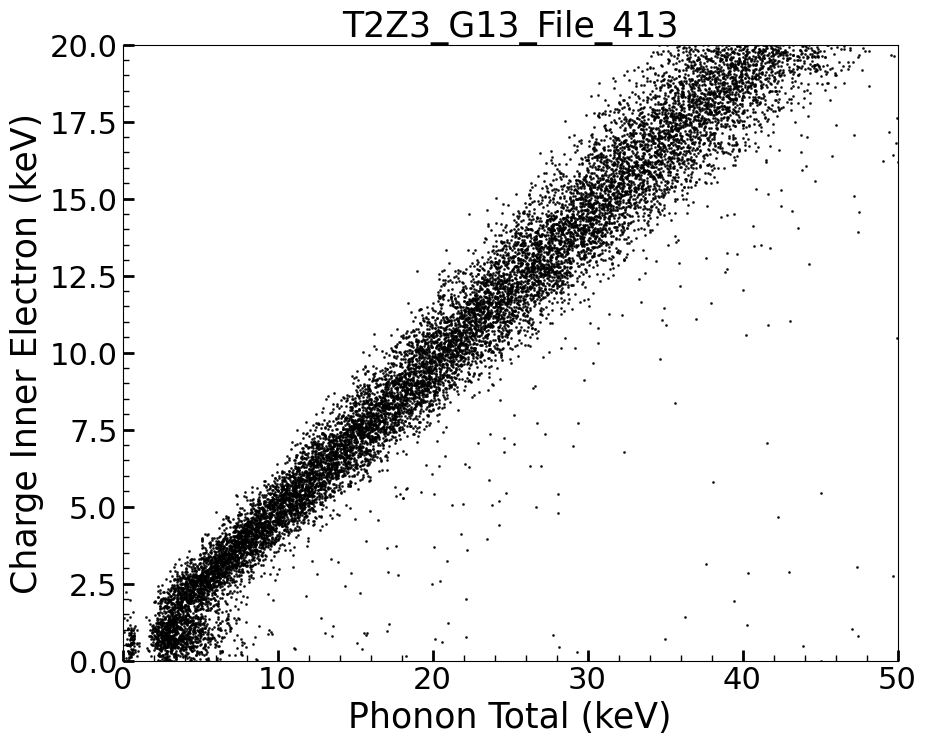

In [2]:


# import Ba data from CDMS
import pandas as pds
import os

directory = "data/Ba_data_germanium/"

detector_ids = pds.read_csv("data/Ge_detector_ids.csv", skiprows=1, \
                         names=['TZ', 'GeSlab', 'Code'], \
                         sep=',')
print(detector_ids)

d_names = np.asarray(detector_ids["TZ"])
d_slabs = np.asarray(detector_ids["GeSlab"])
d_codes = np.asarray(detector_ids["Code"])
print(d_codes)
#d_codes = [405]

#print(d_names)
#print(d_codes)

for file in os.listdir(directory):
    
    #print(file)
    if file.find('.csv')<0:
        continue
    # reading in a data file 
    file = os.fsdecode(file)
    fname = os.path.join(directory, file)
    #print(fname)
    
    # matching fname to detector name
    #print(fname)
    fcode = fname[31:34]
    #print(fcode)
    if int(fcode) not in d_codes:
        continue
    title = "nan"
    
    for x in range(0, len(d_codes)):
        #print(d_codes[x])
        #print(fcode)
        if int(d_codes[x]) == int(fcode):
            title = str(d_names[x]) + "_" + str(d_slabs[x]) + "_File_" + str(d_codes[x])
            print(title)
        else:
            continue
        
    ptqi_data = pds.read_csv(fname, skiprows=1, \
                         names=['pt', 'qi'], \
                         sep=',')

    ptqi_data = ptqi_data.sort_values(by='pt',ascending=False)
    #print(ptqi_data.head(100))

    pt = np.asarray(ptqi_data["pt"])
    qi = np.asarray(ptqi_data["qi"])
    
    # # creating 2D histogram of qi vs pt to visualize ER and NR bands
    fig, axs = plt.subplots(1,1,figsize=(10,8))
    ax1 = axs
    
    #choose colormap, change in 2 places below
    cmap1 = 'magma'
    cmap2 = 'twilight'
    
    #change colormap here !!!
    #h1 = ax1.hist2d(pt, qi, bins=100, cmap=cmap2, range=np.array([(0, 50), (0, 20)]), cmin=0, cmax=50)
    #plt.colorbar(h1[3],fraction=0.046,pad=0.02)
    
    plt.plot(pt, qi, 'ko', alpha=0.8, markersize=1)
    
    ax1.set_xlim(0, 50) #in pairs
    ax1.set_ylim(0,20)

    plt.title(str(title), fontsize=25)
    plt.xlabel("Phonon Total (keV)", fontsize=25)
    plt.ylabel("Charge Inner Electron (keV)", fontsize=25)
    
    #change colormap here !!!
    #plt.savefig(f'figures/Ba_{title}_{cmap1}.png')
    plt.show()

In [3]:
file = os.listdir(directory)[1]

fname = os.path.join(directory, file)
print(fname)
ptqi_data = pds.read_csv(fname, skiprows=1, \
                         names=['pt', 'qi'], \
                         sep=',')

ptqi_data = ptqi_data.sort_values(by='pt',ascending=False)
#print(ptqi_data.head(100))

pt = np.asarray(ptqi_data["pt"])
qi = np.asarray(ptqi_data["qi"])

data/Ba_data_germanium/Ba_ptqi_444.csv


In [4]:
max_x_points = 100
min_x_points = 0

m = 0.47
b = -2
pt_line = np.linspace(min_x_points,max_x_points,100)
qi_line = pt_line*m +b
ax1.plot(pt_line, qi_line, 'r', alpha=0.8, markersize=1)

cNoER = (qi<(pt*m+b))&(pt<=max_x_points)&(pt>min_x_points)

pt_kern = pt[cNoER]
qi_kern = qi[cNoER]

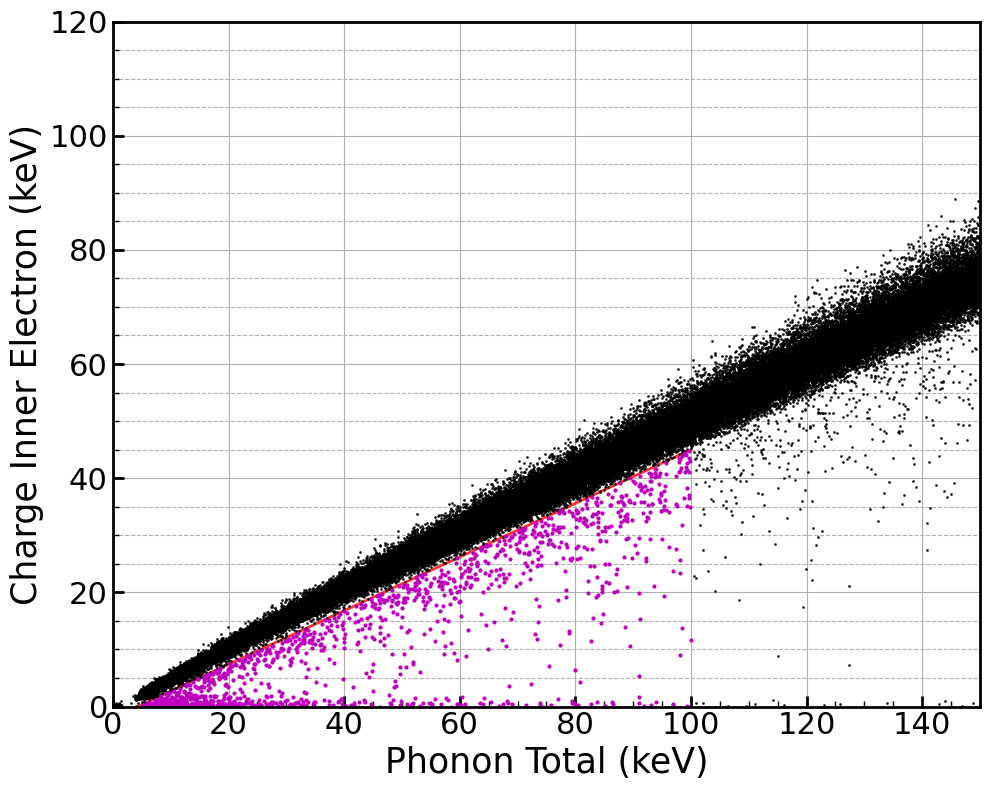

In [5]:
# # creating 2D histogram of qi vs pt to visualize ER and NR bands
fig, axs = plt.subplots(1,1,figsize=(10,8))
ax1 = axs

    
#choose colormap, change in 2 places below
cmap1 = 'magma'
cmap2 = 'twilight'
    
#change colormap here !!!
#h1 = ax1.hist2d(pt, qi, bins=100, cmap=cmap2, range=np.array([(0, 50), (0, 20)]), cmin=0, cmax=50)
#plt.colorbar(h1[3],fraction=0.046,pad=0.02)
ax1.plot(pt_line, qi_line, 'r', alpha=0.8, markersize=1)
    
ax1.plot(pt, qi, 'ko', alpha=0.8, markersize=1)
ax1.plot(pt_kern, qi_kern, 'mo', alpha=1, markersize=2)
    
ax1.set_xlim(0, 150) #in pairs
ax1.set_ylim(0,120)

ax1.set_xlabel("Phonon Total (keV)", fontsize=25)
ax1.set_ylabel("Charge Inner Electron (keV)", fontsize=25)

ax1.grid(True)
ax1.yaxis.grid(True,which='minor',linestyle='--')
#ax1.legend(loc=1,prop={'size':20})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
plt.show()
    
#change colormap here !!!
#plt.savefig(f'figures/Ba_{title}_{cmap1}.png')

In [6]:
xmin=0
xmax=max_x_points
ymin=0
ymax=max_x_points*0.5


from scipy import stats
X, Y = np.mgrid[xmin:xmax:1000j, ymin:ymax:1000j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([pt_kern, qi_kern])
kernel = stats.gaussian_kde(values,bw_method='silverman')
Z = np.reshape(kernel(positions).T, X.shape)

In [7]:
%%capture
'''import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
          extent=[xmin, xmax, ymin, ymax])
ax.plot(pt_line, qi_line, 'r', alpha=0.8, markersize=1)
#ax.plot(m1, m2, 'k.', markersize=2)
ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, ymax])
plt.show()'''

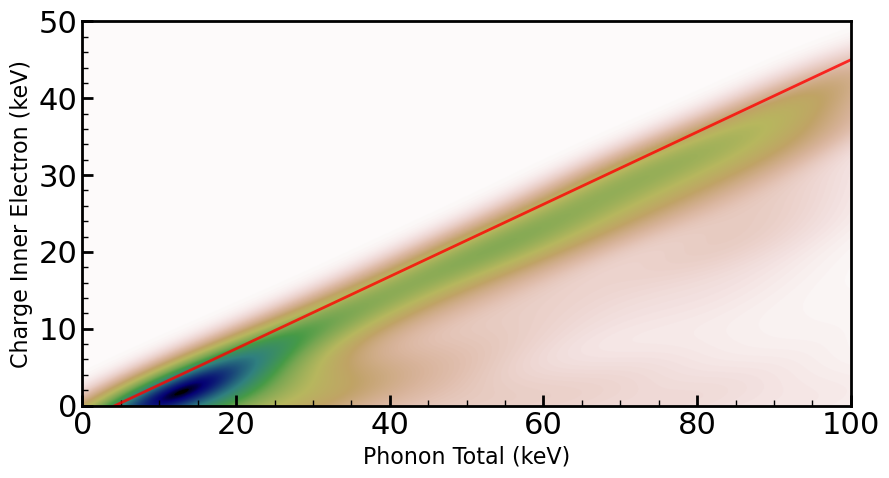

In [8]:
# # creating 2D histogram of qi vs pt to visualize ER and NR bands
fig, axs = plt.subplots(1,1,figsize=(9.0,8.0),sharex=True)
ax1 = axs

ax1.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
          extent=[xmin, xmax, ymin, ymax])
ax1.plot(pt_line, qi_line, 'r', alpha=0.8, markersize=1)
#ax.plot(m1, m2, 'k.', markersize=2)
ax1.set_xlim([xmin, xmax])
ax1.set_ylim([ymin, ymax])

ax1.set_xlabel("Phonon Total (keV)", fontsize=16)
ax1.set_ylabel("Charge Inner Electron (keV)", fontsize=16)

#ax1.grid(True)
#ax1.yaxis.grid(True,which='minor',linestyle='--')
#ax1.legend(loc=1,prop={'size':20})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
plt.show()

In [9]:
print(np.shape(positions))

(2, 1000000)


In [10]:
print(kernel([20,5]))

[0.00153044]


In [11]:
from lintsampler import LintSampler

In [12]:
f = lambda x,y: kernel([x,y])[0]

print(f(20,5))

def ftup(a):
    return f(a[0],a[1])

a = np.asarray([20,5])

print(ftup(a))

ngrid=100
x = np.linspace(xmin, xmax, ngrid)
y = np.linspace(ymin, ymax, ngrid)
sampler = LintSampler((x, y), ftup)
pts = sampler.sample(N=1000)

0.0015304357375635345
0.0015304357375635345


In [15]:
%%capture
print(pts[:,0])
print(np.shape(pts[:,0]))
print(np.shape(pts[:,1]))

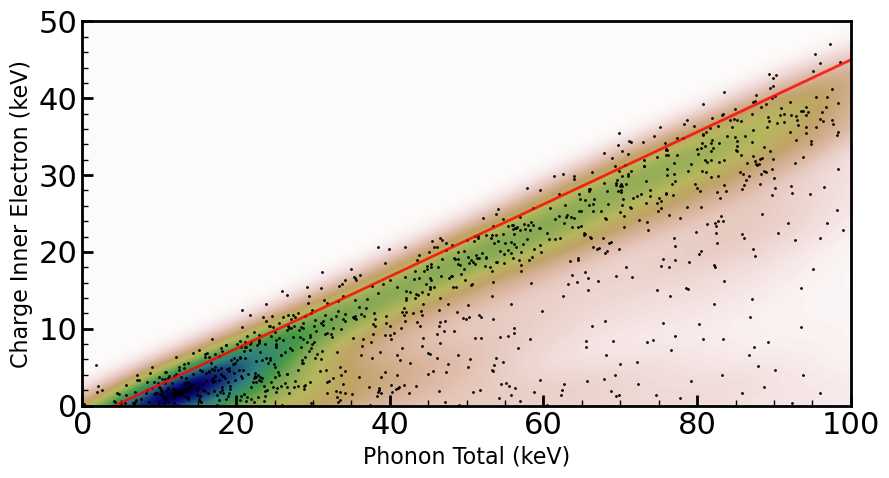

In [14]:
# # creating 2D histogram of qi vs pt to visualize ER and NR bands
fig, axs = plt.subplots(1,1,figsize=(9.0,8.0),sharex=True)
ax1 = axs

ax1.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
          extent=[xmin, xmax, ymin, ymax])
ax1.plot(pt_line, qi_line, 'r', alpha=0.8, markersize=1)
ax1.scatter(pts[:,0],pts[:,1],s=1,color='k')
#ax.plot(m1, m2, 'k.', markersize=2)
ax1.set_xlim([xmin, xmax])
ax1.set_ylim([ymin, ymax])

ax1.set_xlabel("Phonon Total (keV)", fontsize=16)
ax1.set_ylabel("Charge Inner Electron (keV)", fontsize=16)

#ax1.grid(True)
#ax1.yaxis.grid(True,which='minor',linestyle='--')
#ax1.legend(loc=1,prop={'size':20})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
plt.show()